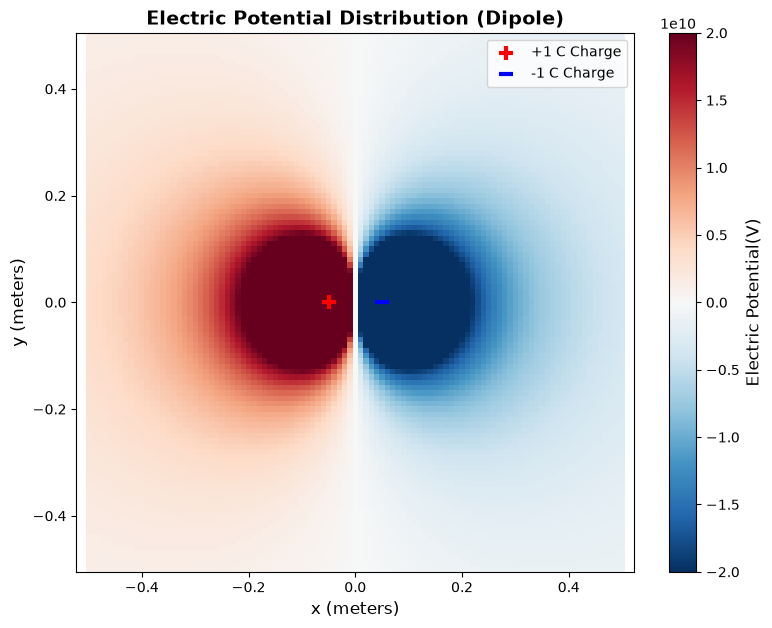

In [2]:
#a
import numpy as np
import pylab as plt

# parameters
q1 = 1
q2 = -1
q = q1*q2
E0 = 8.854e-12

# to create grid
x = np.arange(-0.5,0.501,0.01)
y = np.arange(-0.5,0.501,0.01)
X,Y = np.meshgrid(x,y)

# total potential
def total_potential(X,Y,x1,y1,x2,y2,q1,q2):
    x1 = -0.05
    x2 = 0.05
    y1 = 0
    y2 = 0
    k = 8.99e9
    r1 = np.sqrt((X-x1)**2 + (Y-y1)**2)
    r2 = np.sqrt((X-x2)**2 + (Y-y2)**2)
    V1 = np.where(r1==0,0,k*q1/r1)
    V2 = np.where(r2==0,0,k*q2/r2)
    V_total = V1 + V2
    return V_total

V_total = total_potential(X,Y,q1=1,x1=0.05,y1=0,q2=-1,x2=-0.05,y2=0)

# graph

plt.figure(figsize=(9,7))

# We limit the color scale using vmin/vmax because the potential becomes excessively high at the charge centers.
# This ensures that color variations far from the charges are also clearly visible.
mesh = plt.pcolormesh(X,Y,V_total,cmap='RdBu_r',vmin=-2e10,vmax=2e10,shading='auto')

# colorbar
cbar = plt.colorbar(mesh)
cbar.set_label('Electric Potential(V)',fontsize=12)

# 4. DISPLAYING LOAD POSITIONS AS DOTS ON THE GRAPH
plt.scatter([-0.05], [0], color='red', s=100, marker='+', linewidths=3, zorder=5, label='+1 C Charge')
plt.scatter([0.05], [0], color='blue', s=100, marker='_', linewidths=3, zorder=5, label='-1 C Charge')

plt.title('Electric Potential Distribution (Dipole)', fontsize=14, fontweight='bold')
plt.xlabel('x (meters)', fontsize=12)
plt.ylabel('y (meters)', fontsize=12)
plt.legend(loc='upper right')

# We make our plane appear as a 1m x 1m square.
plt.axis('equal')

plt.show()




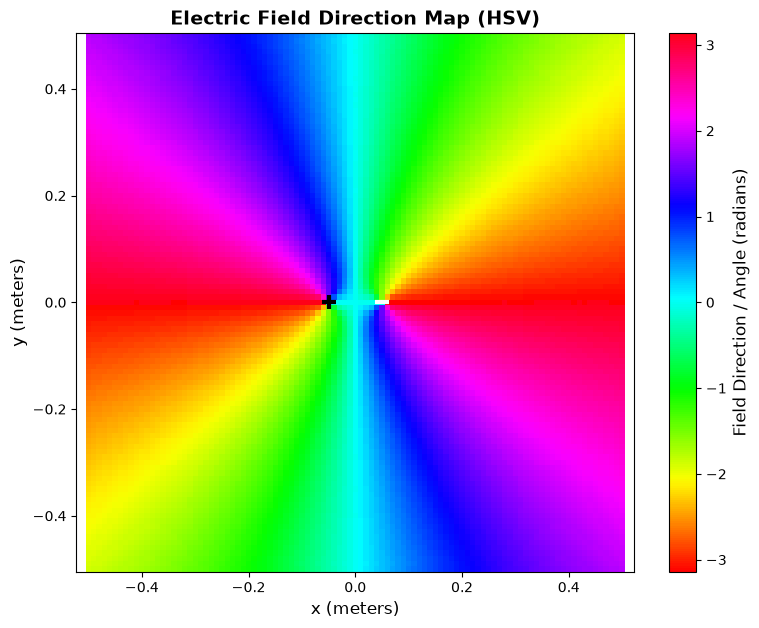

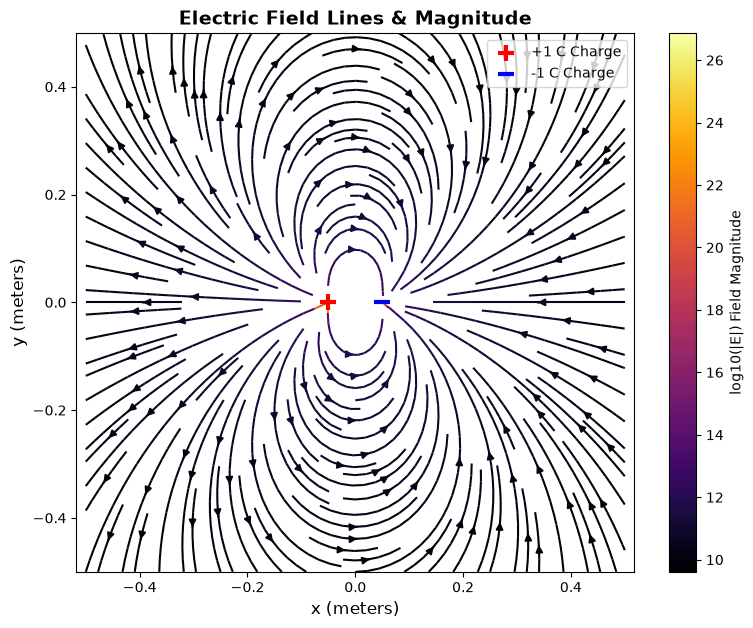

In [4]:

#b

import numpy as np
import matplotlib.pyplot as plt

# Our grid step size (1 cm = 0.01 m)
dx = 0.01
dy = 0.01

# 1. Calculating electric field components (E = -grad(V))
# We take the x and y derivatives of the V_total matrix.
Ey, Ex = np.gradient(-V_total, dy, dx)

# 2. CALCULATION OF MAGNITUDE AND ANGLE (DIRECTION)
E_mag = np.sqrt(Ex**2 + Ey**2)
E_angle = np.arctan2(Ey, Ex)  # Direction angle in radians

# VISUALIZATION 1 (DIRECTION MAP)
plt.figure(figsize=(9, 7))

mesh_dir = plt.pcolormesh(X, Y, E_angle, cmap='hsv', shading='auto')
cbar_dir = plt.colorbar(mesh_dir)
cbar_dir.set_label('Field Direction / Angle (radians)', fontsize=12)

# Let's mark the locations of the loads.
plt.scatter([-0.05], [0], color='black', s=100, marker='+', linewidths=3, zorder=5)
plt.scatter([0.05], [0], color='white', s=100, marker='_', linewidths=3, zorder=5)

plt.title('Electric Field Direction Map (HSV)', fontsize=14, fontweight='bold')
plt.xlabel('x (meters)', fontsize=12)
plt.ylabel('y (meters)', fontsize=12)
plt.axis('equal')
plt.show()

# VISUALIZATION 2 (ELECTRIC FIELD LINES (STREAMPLOT))
plt.figure(figsize=(9, 7))

# Streamplot draws field lines from positive charge to negative charge
plt.streamplot(X, Y, Ex, Ey, color=np.log10(E_mag), cmap='inferno', density=1.5)
plt.colorbar(label='log10(|E|) Field Magnitude')

plt.scatter([-0.05], [0], color='red', s=120, marker='+', linewidths=3, zorder=5, label='+1 C Charge')
plt.scatter([0.05], [0], color='blue', s=120, marker='_', linewidths=3, zorder=5, label='-1 C Charge')

plt.title('Electric Field Lines & Magnitude', fontsize=14, fontweight='bold')
plt.xlabel('x (meters)', fontsize=12)
plt.ylabel('y (meters)', fontsize=12)
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

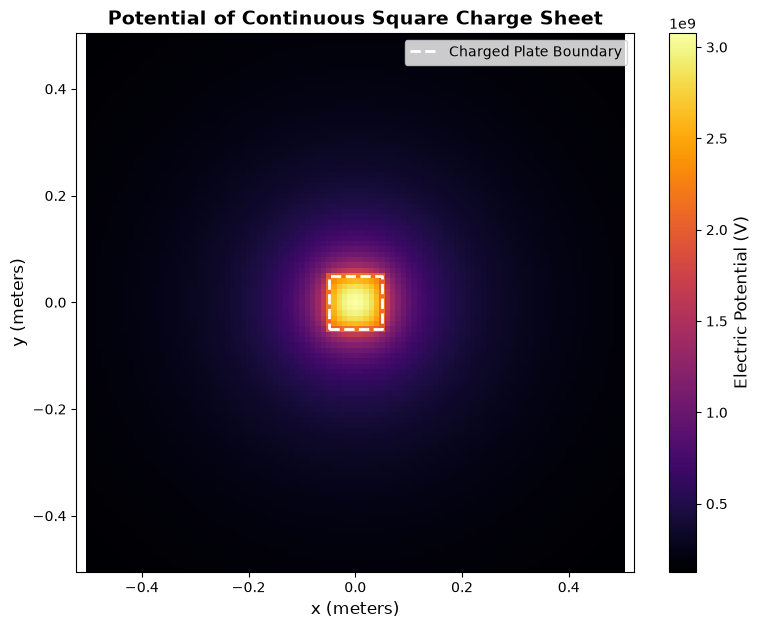

In [8]:
#c
import numpy as np
import matplotlib.pyplot as plt

# observation grid (1m x 1m Area Where Potential Will Be Measured)
x = np.arange(-0.5, 0.501, 0.01)
y = np.arange(-0.5, 0.501, 0.01)
X, Y = np.meshgrid(x, y)

# definition and division of the continuous load plate
L = 0.1          # Side length of the plate (10 cm = 0.1 m)
sigma = 1.0      # Surface charge density (1 Coulomb / m²)
k = 8.99e9       # Coulomb constant

# We divide the plate into 50x50 = 2500 small particles (dq) for the integral.
N_plate = 50
dx_p = L / N_plate
dy_p = L / N_plate
x_prime = np.linspace(-L/2, L/2, N_plate)
y_prime = np.linspace(-L/2, L/2, N_plate)

# The dimensions of each micro-square and the amount of charge it carries (dq = sigma * dx' * dy')
dq = sigma * dx_p * dy_p

# Numerical integral (double integral / superposition sum)
V_continuous = np.zeros_like(X)

for xp in x_prime:
    for yp in y_prime:
        # Distance of all grid points to the instantaneous load element (xp, yp)
        r = np.sqrt((X - xp)**2 + (Y - yp)**2)
        r = np.maximum(r, 1e-4)  # Preventing division by zero
        
       # add the potential created by the dq charge to the matrix
        V_continuous += k * dq / r

# Visualization (density plot)
plt.figure(figsize=(9, 7))

# Plotting the potential map
mesh = plt.pcolormesh(X, Y, V_continuous, cmap='inferno', shading='auto')
cbar = plt.colorbar(mesh)
cbar.set_label('Electric Potential (V)', fontsize=12)

# Marking the physical boundaries of the loaded plate with a vertical dashed white line
plate_box_x = [-L/2, L/2, L/2, -L/2, -L/2]
plate_box_y = [-L/2, -L/2, L/2, L/2, -L/2]
plt.plot(plate_box_x, plate_box_y, 'w--', linewidth=2, label='Charged Plate Boundary')

plt.title('Potential of Continuous Square Charge Sheet', fontsize=14, fontweight='bold')
plt.xlabel('x (meters)', fontsize=12)
plt.ylabel('y (meters)', fontsize=12)
plt.legend(loc='upper right')
plt.axis('equal')

plt.show()